# S14 - Proyecto de pruebas A/B

## Introduccion

Has recibido una tarea analítica de una tienda en línea internacional. Tus predecesores no consiguieron completarla: lanzaron una prueba A/B y luego abandonaron. Solo dejaron las especificaciones técnicas y los resultados de las pruebas.

Tienes que analizar los resultados de la prueba, y definir su se ha realizado correctamente.

La informacion que se proporciona para el analisis es:
- Un archivo con el calendario de eventos de marketing para 2020.
- Un archivo con los usuarios que se registraron en la tienda en línea desde el 7 hasta el 21 de diciembre de 2020.
- Un archivo con los eventos de los nuevos usuarios en el período entre el 7 de diciembre de 2020 y el 1 de enero de 2021.
- Un archivo con los datos de los participantes de la prueba.

Lo que solicitan investigar es:
- Analizar el test A/B, representar graficamente los resultados, determinar la significancia estadistica de los mismos y tomar una decision con base en las pruebas de hipotesis.

## Diccionario de datos

**Tabla ab_project_marketing_events_us:** archivo con el calendario de eventos de marketing para 2020.

- `name:` el nombre del evento de marketing.
- `regions:` regiones donde se llevará a cabo la campaña publicitaria.
- `start_dt:` fecha de inicio de la campaña.
- `finish_dt:` fecha de finalización de la campaña.

**Tabla final_ab_new_users_upd_us:** archivo con los usuarios que se registraron en la tienda en línea desde el 7 hasta el 21 de diciembre de 2020.

- `user_id:` identificador del usuario.
- `first_date:` fecha de inscripción.
- `region:` region del usuario.
- `device:` dispositivo utilizado para la inscripción.

**Tabla final_ab_events_upd_us:** archivo con los eventos de los nuevos usuarios en el período entre el 7 de diciembre de 2020 y el 1 de enero de 2021.

- `user_id:` identificador del usuario.
- `event_dt:` fecha y hora del evento.
- `event_name:` nombre del tipo de evento.
- `details:` datos adicionales sobre el evento (por ejemplo, el pedido total en USD para los eventos purchase).

**Tabla final_ab_participants_upd_us:** Un archivo con los datos de los participantes de la prueba.
- `user_id:` identificador del usuario.
- `ab_test:` nombre de la prueba.
- `group:` el grupo de prueba al que pertenecía el usuario.

## Carga de librerias y conjunto de datos

In [1]:
#Carga de liberias

#Manejo de datos
import pandas as pd
import numpy as np
from datetime import timedelta
from datetime import datetime

#Visualizaciones
from matplotlib import pyplot as plt

#Analisis estadistico
import scipy.stats as stats
import statsmodels.stats.api as sms
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

In [2]:
#Carga de base de datos 1
df_calendar = pd.read_csv('/datasets/ab_project_marketing_events_us.csv')#, sep=';')
print(df_calendar)
print()
df_calendar.info()

                                name                   regions    start_dt  \
0           Christmas&New Year Promo             EU, N.America  2020-12-25   
1       St. Valentine's Day Giveaway  EU, CIS, APAC, N.America  2020-02-14   
2             St. Patric's Day Promo             EU, N.America  2020-03-17   
3                       Easter Promo  EU, CIS, APAC, N.America  2020-04-12   
4                  4th of July Promo                 N.America  2020-07-04   
5          Black Friday Ads Campaign  EU, CIS, APAC, N.America  2020-11-26   
6             Chinese New Year Promo                      APAC  2020-01-25   
7   Labor day (May 1st) Ads Campaign             EU, CIS, APAC  2020-05-01   
8    International Women's Day Promo             EU, CIS, APAC  2020-03-08   
9    Victory Day CIS (May 9th) Event                       CIS  2020-05-09   
10         CIS New Year Gift Lottery                       CIS  2020-12-30   
11     Dragon Boat Festival Giveaway                      APAC  

In [3]:
#Carga de base de datos 2
df_users = pd.read_csv('/datasets/final_ab_new_users_upd_us.csv')#, sep=';')
print(df_users)
print()
df_users.info()

                user_id  first_date     region   device
0      D72A72121175D8BE  2020-12-07         EU       PC
1      F1C668619DFE6E65  2020-12-07  N.America  Android
2      2E1BF1D4C37EA01F  2020-12-07         EU       PC
3      50734A22C0C63768  2020-12-07         EU   iPhone
4      E1BDDCE0DAFA2679  2020-12-07  N.America   iPhone
...                 ...         ...        ...      ...
58698  1DB53B933257165D  2020-12-20         EU  Android
58699  538643EB4527ED03  2020-12-20         EU      Mac
58700  7ADEE837D5D8CBBD  2020-12-20         EU       PC
58701  1C7D23927835213F  2020-12-20         EU   iPhone
58702  8F04273BB2860229  2020-12-20         EU  Android

[58703 rows x 4 columns]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-null  object
 1   first_date  58703 non-null  object
 2   region      58703 non-null  

In [4]:
#Carga de base de datos 3
df_events = pd.read_csv('/datasets/final_ab_events_upd_us.csv')#, sep=';')
print(df_events)
print()
df_events.info()

                 user_id             event_dt event_name  details
0       E1BDDCE0DAFA2679  2020-12-07 20:22:03   purchase    99.99
1       7B6452F081F49504  2020-12-07 09:22:53   purchase     9.99
2       9CD9F34546DF254C  2020-12-07 12:59:29   purchase     4.99
3       96F27A054B191457  2020-12-07 04:02:40   purchase     4.99
4       1FD7660FDF94CA1F  2020-12-07 10:15:09   purchase     4.99
...                  ...                  ...        ...      ...
423756  245E85F65C358E08  2020-12-30 19:35:55      login      NaN
423757  9385A108F5A0A7A7  2020-12-30 10:54:15      login      NaN
423758  DB650B7559AC6EAC  2020-12-30 10:59:09      login      NaN
423759  F80C9BDDEA02E53C  2020-12-30 09:53:39      login      NaN
423760  7AEC61159B672CC5  2020-12-30 11:36:13      login      NaN

[423761 rows x 4 columns]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      -----------

In [5]:
#Carga de base de datos 4
df_test = pd.read_csv('/datasets/final_ab_participants_upd_us.csv')#, sep=';')
print(df_test)
print()
df_test.info()

                user_id group                  ab_test
0      D1ABA3E2887B6A73     A  recommender_system_test
1      A7A3664BD6242119     A  recommender_system_test
2      DABC14FDDFADD29E     A  recommender_system_test
3      04988C5DF189632E     A  recommender_system_test
4      4FF2998A348C484F     A  recommender_system_test
...                 ...   ...                      ...
14520  1D302F8688B91781     B        interface_eu_test
14521  3DE51B726983B657     A        interface_eu_test
14522  F501F79D332BE86C     A        interface_eu_test
14523  63FBE257B05F2245     A        interface_eu_test
14524  79F9ABFB029CF724     B        interface_eu_test

[14525 rows x 3 columns]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
dtypes: object(3)
me

## Procesamiento de los datos

### Columna "start_dt" (df_calendar) 

In [6]:
#Valores en columna start_dt
df_calendar['start_dt']

0     2020-12-25
1     2020-02-14
2     2020-03-17
3     2020-04-12
4     2020-07-04
5     2020-11-26
6     2020-01-25
7     2020-05-01
8     2020-03-08
9     2020-05-09
10    2020-12-30
11    2020-06-25
12    2020-11-11
13    2020-10-01
Name: start_dt, dtype: object

In [7]:
#Conversion de datos de object a datetime
df_calendar['start_dt'] = pd.to_datetime(df_calendar['start_dt'])
df_calendar['start_dt']

0    2020-12-25
1    2020-02-14
2    2020-03-17
3    2020-04-12
4    2020-07-04
5    2020-11-26
6    2020-01-25
7    2020-05-01
8    2020-03-08
9    2020-05-09
10   2020-12-30
11   2020-06-25
12   2020-11-11
13   2020-10-01
Name: start_dt, dtype: datetime64[ns]

**Comments**: se hace el cambio de tipo de dato para esta columna de object a datetime.

### Columna "finish_dt" (df_calendar) 

In [8]:
#Valores en columna finish_dt
df_calendar['finish_dt']

0     2021-01-03
1     2020-02-16
2     2020-03-19
3     2020-04-19
4     2020-07-11
5     2020-12-01
6     2020-02-07
7     2020-05-03
8     2020-03-10
9     2020-05-11
10    2021-01-07
11    2020-07-01
12    2020-11-12
13    2020-10-07
Name: finish_dt, dtype: object

In [9]:
#Conversion de datos de object a datetime
df_calendar['finish_dt'] = pd.to_datetime(df_calendar['finish_dt'])
df_calendar['finish_dt']

0    2021-01-03
1    2020-02-16
2    2020-03-19
3    2020-04-19
4    2020-07-11
5    2020-12-01
6    2020-02-07
7    2020-05-03
8    2020-03-10
9    2020-05-11
10   2021-01-07
11   2020-07-01
12   2020-11-12
13   2020-10-07
Name: finish_dt, dtype: datetime64[ns]

**Comments**: se hace el cambio de tipo de dato para esta columna de object a datetime.

### Identificacion de valores duplicados (df_calendar)

In [10]:
#Validacion de lineas duplicadas completas 
df_calendar[df_calendar.duplicated()]

,name,regions,start_dt,finish_dt


**Comments**: no se identifican valores duplicados en lineas completas.

### Columna "first_date" (df_users) 

In [11]:
#Valores en columna first_date
df_users['first_date']

0        2020-12-07
1        2020-12-07
2        2020-12-07
3        2020-12-07
4        2020-12-07
            ...    
58698    2020-12-20
58699    2020-12-20
58700    2020-12-20
58701    2020-12-20
58702    2020-12-20
Name: first_date, Length: 58703, dtype: object

In [12]:
#Conversion de datos de object a datetime
df_users['first_date'] = pd.to_datetime(df_users['first_date'])
df_users['first_date']

0       2020-12-07
1       2020-12-07
2       2020-12-07
3       2020-12-07
4       2020-12-07
           ...    
58698   2020-12-20
58699   2020-12-20
58700   2020-12-20
58701   2020-12-20
58702   2020-12-20
Name: first_date, Length: 58703, dtype: datetime64[ns]

**Comments**: se hace el cambio de tipo de dato para esta columna de object a datetime.

### Columna "region" (df_users) 

In [13]:
#Valores en columna region
df_users['region']

0               EU
1        N.America
2               EU
3               EU
4        N.America
           ...    
58698           EU
58699           EU
58700           EU
58701           EU
58702           EU
Name: region, Length: 58703, dtype: object

In [14]:
#Identificacion de volumen de datos por region
df_users['region'].value_counts(dropna=False).sort_values(ascending=False)

EU           43396
N.America     9051
CIS           3130
APAC          3126
Name: region, dtype: int64

**Comments**: el tipo de dato para esta columna es el adecuado. Se identifica que hay 43.3k usuarios de EU, 9k de NA y 3k de CIS y APAC respectivamente.

**Significado de siglas:**
- https://supporthub.g2a.com/marketplace/en/digital-items/region-restrictions--globaleuropeamericarow-what-does-it-mean

### Columna "device" (df_users) 

In [15]:
#Valores en columna device
df_users['device']

0             PC
1        Android
2             PC
3         iPhone
4         iPhone
          ...   
58698    Android
58699        Mac
58700         PC
58701     iPhone
58702    Android
Name: device, Length: 58703, dtype: object

In [16]:
#Identificacion de volumen de datos por device
df_users['device'].value_counts(dropna=False).sort_values(ascending=False)

Android    26159
PC         14845
iPhone     11902
Mac         5797
Name: device, dtype: int64

**Comments**: el tipo de dato para esta columna es el adecuado. Se identifica que hay 26.1k dispositivos Android, 14.8k de PCs, 11.9k iPhones y 5.7k Mac.

### Identificacion de valores duplicados (df_users)

In [17]:
#Validacion de lineas duplicadas completas 
df_users[df_users.duplicated()]

,user_id,first_date,region,device


**Comments**: no se identifican valores duplicados en lineas completas.

### Columna "user_id" (df_events) 

In [18]:
#Valores en columna user_id
df_events['user_id']

0         E1BDDCE0DAFA2679
1         7B6452F081F49504
2         9CD9F34546DF254C
3         96F27A054B191457
4         1FD7660FDF94CA1F
                ...       
423756    245E85F65C358E08
423757    9385A108F5A0A7A7
423758    DB650B7559AC6EAC
423759    F80C9BDDEA02E53C
423760    7AEC61159B672CC5
Name: user_id, Length: 423761, dtype: object

In [19]:
#Identificacion de volumen de datos por user_id
df_events['user_id'].value_counts(dropna=False).sort_values(ascending=False)

A3917F81482141F2    36
203773F2A53233A8    32
8AEB716C4CD82CA7    32
11285A53EC2B2042    32
426330B820B8711A    32
                    ..
82D45F8F96C273F6     1
95C9049F257380C5     1
02D9097D76789498     1
50ABB2D2B9FFE80B     1
9A95112CF1560AC8     1
Name: user_id, Length: 58703, dtype: int64

**Comments**: el tipo de dato para esta columna es el adecuado. Se identifica que los usuarios con mayor cantidad de eventos es de +30 y la menor cantidad es de 1.

### Columna "event_dt" (df_events) 

In [20]:
#Valores en columna event_dt
df_events['event_dt']

0         2020-12-07 20:22:03
1         2020-12-07 09:22:53
2         2020-12-07 12:59:29
3         2020-12-07 04:02:40
4         2020-12-07 10:15:09
                 ...         
423756    2020-12-30 19:35:55
423757    2020-12-30 10:54:15
423758    2020-12-30 10:59:09
423759    2020-12-30 09:53:39
423760    2020-12-30 11:36:13
Name: event_dt, Length: 423761, dtype: object

In [21]:
#Conversion de datos de object a datetime
df_events['event_dt'] = df_events['event_dt'].astype('datetime64[D]')
df_events['event_dt']

0        2020-12-07
1        2020-12-07
2        2020-12-07
3        2020-12-07
4        2020-12-07
            ...    
423756   2020-12-30
423757   2020-12-30
423758   2020-12-30
423759   2020-12-30
423760   2020-12-30
Name: event_dt, Length: 423761, dtype: datetime64[ns]

**Comments**: se hace el cambio de tipo de dato para esta columna de object a datetime.

### Columna "event_name" (df_events) 

In [22]:
#Valores en columna event_name
df_events['event_name']

0         purchase
1         purchase
2         purchase
3         purchase
4         purchase
            ...   
423756       login
423757       login
423758       login
423759       login
423760       login
Name: event_name, Length: 423761, dtype: object

In [23]:
#Identificacion de volumen de datos por event_name
df_events['event_name'].value_counts(dropna=False).sort_values(ascending=False)

login           182465
product_page    120862
purchase         60314
product_cart     60120
Name: event_name, dtype: int64

**Comments**: el tipo de dato para esta columna es el adecuado. Se identifica el volumen de eventos siendo login el mayor con 182k, seguido de product_page 120k, purchase 60.3k y product_cart 60.1k.

### Columna "details" (df_events) 

In [24]:
#Valores en columna details
df_events['details']

0         99.99
1          9.99
2          4.99
3          4.99
4          4.99
          ...  
423756      NaN
423757      NaN
423758      NaN
423759      NaN
423760      NaN
Name: details, Length: 423761, dtype: float64

In [25]:
#Identificacion de volumen de datos por details
df_events['details'].value_counts(dropna=False).sort_values(ascending=False)

NaN       363447
4.99       44579
9.99        9158
99.99       5405
499.99      1172
Name: details, dtype: int64

**Comments**: el tipo de dato para esta columna es el adecuado. Se identifica que el total de valores no ausentes es igual a la cantidad de purchases (60.3k). Tambien que el valor minimo de 4.99 es el mas frecuente (44.5k) y el valor maximo de 499.99 es el menos frecuente (1.1k).

### Identificacion de valores duplicados (df_events)

In [26]:
#Validacion de lineas duplicadas completas 
df_events[df_events.duplicated()]

,user_id,event_dt,event_name,details
41759,72C55C38CAE0B00B,2020-12-21,purchase,4.99
367557,72C55C38CAE0B00B,2020-12-21,login,NaN


**Comments**: no se identifican valores duplicados en lineas completas.

### Columna "user_id" (df_test) 

In [27]:
#Valores en columna user_id
df_test['user_id']

0        D1ABA3E2887B6A73
1        A7A3664BD6242119
2        DABC14FDDFADD29E
3        04988C5DF189632E
4        4FF2998A348C484F
               ...       
14520    1D302F8688B91781
14521    3DE51B726983B657
14522    F501F79D332BE86C
14523    63FBE257B05F2245
14524    79F9ABFB029CF724
Name: user_id, Length: 14525, dtype: object

In [28]:
#Identificacion de volumen de datos por user_id
df_test['user_id'].value_counts(dropna=False).sort_values(ascending=False)

A0028F574B5E5DC6    2
9CBD8387C8A1DDDF    2
13AE4DFAC67ACEB3    2
4C3B9B6D59E98D59    2
74285DE881A72F4C    2
                   ..
4ABDA1E795AAD57F    1
20B97D9922A0D0F8    1
BD89A36FAEB716EA    1
92BEBEDF561F6C12    1
D3834632B7055884    1
Name: user_id, Length: 13638, dtype: int64

**Comments**: el tipo de dato para esta columna es el adecuado. Se identifica que hay usuarios que aparecen 2 veces en el dataset y otros solo una.

### Columna "group" (df_test) 

In [29]:
#Valores en columna group
df_test['group']

0        A
1        A
2        A
3        A
4        A
        ..
14520    B
14521    A
14522    A
14523    A
14524    B
Name: group, Length: 14525, dtype: object

In [30]:
#Identificacion de volumen de datos por user_id
df_test['group'].value_counts(dropna=False).sort_values(ascending=False)

A    8214
B    6311
Name: group, dtype: int64

**Comments**: el tipo de dato para esta columna es el adecuado. Se identifican 8.2k usuarios en el grupo A y 6.3k en el grupo B.

### Columna "ab_test" (df_test) 

In [31]:
#Valores en columna ab_test
df_test['ab_test']

0        recommender_system_test
1        recommender_system_test
2        recommender_system_test
3        recommender_system_test
4        recommender_system_test
                  ...           
14520          interface_eu_test
14521          interface_eu_test
14522          interface_eu_test
14523          interface_eu_test
14524          interface_eu_test
Name: ab_test, Length: 14525, dtype: object

In [32]:
#Identificacion de volumen de datos por user_id
df_test['ab_test'].value_counts(dropna=False).sort_values(ascending=False)

interface_eu_test          10850
recommender_system_test     3675
Name: ab_test, dtype: int64

**Comments**: el tipo de dato para esta columna es el adecuado. Se identifican 10.8k pruebas de interface y 3.6k pruebas de recommender.

### Identificacion de valores duplicados (df_test)

In [33]:
#Validacion de lineas duplicadas completas 
df_test[df_test.duplicated()]

,user_id,group,ab_test


**Comments**: no se identifican valores duplicados en lineas completas.

## Analisis Exploratorio

### Estudia la conversión en las diferentes etapas del embudo.

In [34]:
#Filtrado de usuarios a recommender_system_test
df_test1 = df_test.query("ab_test == 'recommender_system_test'")
df_test1.sample(5, random_state=24)

,user_id,group,ab_test
2912,4A4D81DBBC67109B,A,recommender_system_test
1941,B36555EE73132491,A,recommender_system_test
1018,CBDCB94D41AA49BC,A,recommender_system_test
3167,6754476B0C2800E1,A,recommender_system_test
1312,47ADBF580CF107E1,B,recommender_system_test


In [35]:
#Revision de duplicados
df_test1['user_id'][df_test1['user_id'].duplicated()]

Series([], Name: user_id, dtype: object)

In [36]:
#Identificacion de usuarios por grupo
df_test1.groupby('group')['user_id'].nunique()

group
A    2747
B     928
Name: user_id, dtype: int64

In [37]:
#Merge de eventos con usuarios
df_events_test1 = df_events.merge(df_test1, on = 'user_id', how = 'inner')
df_events_test1

,user_id,event_dt,event_name,details,group,ab_test
0,831887FE7F2D6CBA,2020-12-07,purchase,4.99,A,recommender_system_test
1,831887FE7F2D6CBA,2020-12-09,purchase,99.99,A,recommender_system_test
2,831887FE7F2D6CBA,2020-12-07,product_cart,NaN,A,recommender_system_test
3,831887FE7F2D6CBA,2020-12-08,product_cart,NaN,A,recommender_system_test
4,831887FE7F2D6CBA,2020-12-09,product_cart,NaN,A,recommender_system_test
...,...,...,...,...,...,...
23904,1E6B9298415AA97A,2020-12-21,login,NaN,B,recommender_system_test
23905,1E6B9298415AA97A,2020-12-22,login,NaN,B,recommender_system_test
23906,1E6B9298415AA97A,2020-12-23,login,NaN,B,recommender_system_test
23907,1E6B9298415AA97A,2020-12-24,login,NaN,B,recommender_system_test


In [38]:
#Identificacion de eventos por grupo
df_events_test1.groupby('group')['user_id'].count()

group
A    18627
B     5282
Name: user_id, dtype: int64

In [39]:
#Pivot de volumen y tipo de evento por dia
df_pivot_A = df_events_test1.query("group == 'A'").pivot_table(index='event_dt', columns='event_name', values='user_id', aggfunc='count')
df_pivot_A.drop(columns='product_cart', inplace=True)
df_pivot_A.rename(columns= {'login':'login_A', 'product_page':'product_page_A', 'purchase':'purchase_A'}, inplace=True)
df_pivot_A.head(8)

event_name,login_A,product_page_A,purchase_A
event_dt,,,
2020-12-07,154,96,46
2020-12-08,159,108,37
2020-12-09,178,106,51
2020-12-10,165,94,46
2020-12-11,185,102,42
2020-12-12,174,96,38
2020-12-13,164,95,35
2020-12-14,488,308,144


In [40]:
#Obtencion de cumsum por tipo de evento
df_pivot_A1 = df_pivot_A.copy()
df_pivot_A1['acum_login_A'] = df_pivot_A1['login_A'].cumsum()
df_pivot_A1['acum_product_page_A'] = df_pivot_A1['product_page_A'].cumsum()
df_pivot_A1['acum_purchase_A'] = df_pivot_A1['purchase_A'].cumsum()
df_pivot_A1 = df_pivot_A1.drop(columns=['login_A', 'product_page_A', 'purchase_A'])
df_pivot_A1.head(8)

event_name,acum_login_A,acum_product_page_A,acum_purchase_A
event_dt,,,
2020-12-07,154,96,46
2020-12-08,313,204,83
2020-12-09,491,310,134
2020-12-10,656,404,180
2020-12-11,841,506,222
2020-12-12,1015,602,260
2020-12-13,1179,697,295
2020-12-14,1667,1005,439


In [41]:
#Pivot de volumen y tipo de evento por dia
df_pivot_B = df_events_test1.query("group == 'B'").pivot_table(index='event_dt', columns='event_name', values='user_id', aggfunc='count')
df_pivot_B.drop(columns='product_cart', inplace=True)
df_pivot_B.drop(df_pivot_B.index[22], inplace=True)
df_pivot_B = df_pivot_B.astype(int)
df_pivot_B.rename(columns= {'login':'login_B', 'product_page':'product_page_B', 'purchase':'purchase_B'}, inplace=True)
df_pivot_B.head(8)

event_name,login_B,product_page_B,purchase_B
event_dt,,,
2020-12-07,165,108,59
2020-12-08,119,64,35
2020-12-09,172,106,40
2020-12-10,131,72,26
2020-12-11,89,46,16
2020-12-12,106,51,25
2020-12-13,87,44,27
2020-12-14,131,67,34


In [42]:
#Obtencion de cumsum por tipo de evento
df_pivot_B1 = df_pivot_B.copy()
df_pivot_B1['acum_login_B'] = df_pivot_B1['login_B'].cumsum()
df_pivot_B1['acum_product_page_B'] = df_pivot_B1['product_page_B'].cumsum()
df_pivot_B1['acum_purchase_B'] = df_pivot_B1['purchase_B'].cumsum()
df_pivot_B1 = df_pivot_B1.drop(columns=['login_B', 'product_page_B', 'purchase_B'])
df_pivot_B1.head(8)

event_name,acum_login_B,acum_product_page_B,acum_purchase_B
event_dt,,,
2020-12-07,165,108,59
2020-12-08,284,172,94
2020-12-09,456,278,134
2020-12-10,587,350,160
2020-12-11,676,396,176
2020-12-12,782,447,201
2020-12-13,869,491,228
2020-12-14,1000,558,262


In [43]:
#Merge de datasets de grupos y obtencion de conversion por eventos
df_conv_dia = df_pivot_A1.merge(df_pivot_B1, on = 'event_dt', how = 'inner')
df_conv_dia['conv_product_A'] = df_conv_dia['acum_product_page_A']/df_conv_dia['acum_login_A']*100
df_conv_dia['conv_purchase_A'] = df_conv_dia['acum_purchase_A']/df_conv_dia['acum_product_page_A']*100
df_conv_dia['conv_product_B'] = df_conv_dia['acum_product_page_B']/df_conv_dia['acum_login_B']*100
df_conv_dia['conv_purchase_B'] = df_conv_dia['acum_purchase_B']/df_conv_dia['acum_product_page_B']*100
df_conv_dia

event_name,acum_login_A,acum_product_page_A,acum_purchase_A,acum_login_B,acum_product_page_B,acum_purchase_B,conv_product_A,conv_purchase_A,conv_product_B,conv_purchase_B
event_dt,,,,,,,,,,
2020-12-07,154,96,46,165,108,59,62.337662,47.916667,65.454545,54.629630
2020-12-08,313,204,83,284,172,94,65.175719,40.686275,60.563380,54.651163
2020-12-09,491,310,134,456,278,134,63.136456,43.225806,60.964912,48.201439
2020-12-10,656,404,180,587,350,160,61.585366,44.554455,59.625213,45.714286
2020-12-11,841,506,222,676,396,176,60.166468,43.873518,58.579882,44.444444
2020-12-12,1015,602,260,782,447,201,59.310345,43.189369,57.161125,44.966443
2020-12-13,1179,697,295,869,491,228,59.117897,42.324247,56.501726,46.435845
2020-12-14,1667,1005,439,1000,558,262,60.287942,43.681592,55.800000,46.953405
2020-12-15,2140,1309,585,1116,612,294,61.168224,44.690604,54.838710,48.039216


<AxesSubplot:title={'center':'Tasas de Conversion login -> product_page'}, xlabel='Date', ylabel='%'>

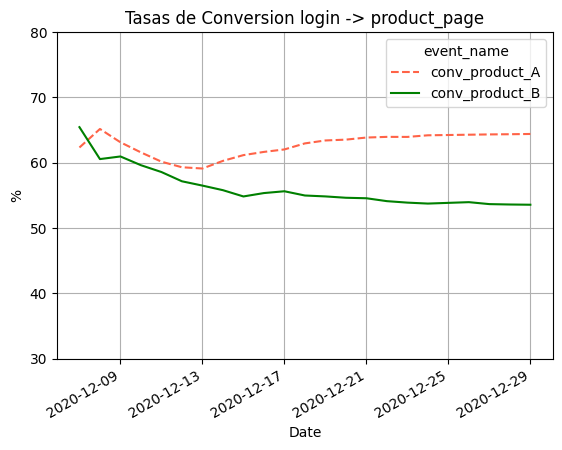

In [44]:
#Grafico de conversion acumulada por dia login -> product_page
df_conv_dia.plot(
    kind = 'line',
    title = 'Tasas de Conversion login -> product_page',
    style=['--','-'],
    y = ['conv_product_A', 'conv_product_B'],
    color=['tomato','green'],
    xlabel = 'Date',
    ylabel = '%',
    grid=True,
    ylim=[30,80]
)

**Comments**: analizando las tazas de conversion por grupo para el paso de login -> product page, se identifica un descontrol del experimento en los primeros dias. Sin embargo a partir del dia 7, se identifica claramente la tendencia de separacion del grupo A con respecto al B con maximos de 11%, los cuales se mantienen constantes por el resto del periodo. 

<AxesSubplot:title={'center':'Tasas de Conversion product_page -> purchase'}, xlabel='Date', ylabel='%'>

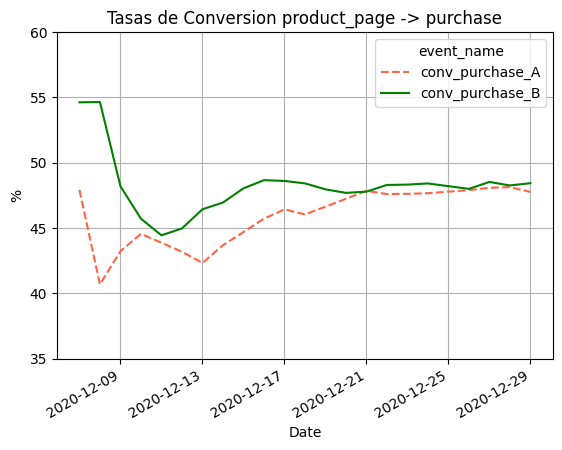

In [45]:
#Grafico de conversion acumulada por dia login -> product_page
df_conv_dia.plot(
    kind = 'line',
    title = 'Tasas de Conversion product_page -> purchase',
    style=['--','-'],
    y = ['conv_purchase_A', 'conv_purchase_B'],
    color=['tomato','green'],
    xlabel = 'Date',
    ylabel = '%',
    grid=True,
    ylim=[35,60]
)

**Comments**: analizando las tazas de conversion por grupo para el paso de product page -> purchase, se identifica un descontrol del experimento en los primeros dias. Sin embargo a partir del dia 11, se estabiliza y reduce la diferencia a favor del grupo B con respecto al A, los cuales se mantienen constantes por el resto del periodo. 

### ¿El número de eventos por usuario está distribuido equitativamente entre las muestras?

In [46]:
#Identificacion de usuarios por grupo
df_test1.groupby('group')['user_id'].nunique()

group
A    2747
B     928
Name: user_id, dtype: int64

In [47]:
2747/928

2.9601293103448274

In [48]:
#Identificacion de eventos por grupo
df_events_test1.groupby('group')['user_id'].count()

group
A    18627
B     5282
Name: user_id, dtype: int64

In [49]:
18627/5282

3.5265051117001134

**Comments**: analizando los datos, no se cuenta con usuarios/eventos distribuidos equitativamente. La cantidad de usuarios por grupo es casi 3 veces mas del A con respecto al B, y en el caso de los eventos es 3.5 veces mas los del A con respecto al B.

### ¿Hay usuarios que están presentes en ambas muestras?

In [50]:
#Validacion de usuarios en ambas mustras en df_test1 
df_test1['user_id'][df_test1['user_id'].duplicated()]

Series([], Name: user_id, dtype: object)

In [51]:
#Validacion de usuarios en ambas mustras en df_events_test1
df_events_test1.groupby(['user_id'])['group'].nunique().sort_values(ascending=False)

user_id
001064FEAAB631A1    1
AAB4D11666ADB943    1
AAD72B195EFC73A4    1
AAE1914BDB419328    1
AAE4A39A0DF719AD    1
                   ..
55E1E5508B640E65    1
55F1DDF55DD42893    1
563FBD5282619D25    1
564975AFF8E15C0C    1
FFF28D02B1EACBE1    1
Name: group, Length: 3675, dtype: int64

**Comments**: analizando ambos datasets, no se encuentran usuarios presentes en ambas muestras.

### ¿Cómo se distribuye el número de eventos entre los días?

In [52]:
#Pivote de eventos por dia
df_pivot_events = df_events_test1.pivot_table(index='event_dt', values='event_name', aggfunc='count')
df_pivot_events

,event_name
event_dt,
2020-12-07,709
2020-12-08,593
2020-12-09,746
2020-12-10,613
2020-12-11,542
2020-12-12,558
2020-12-13,504
2020-12-14,1355
2020-12-15,1316


<AxesSubplot:title={'center':'Distribucion de eventos por dias'}, xlabel='event_dt'>

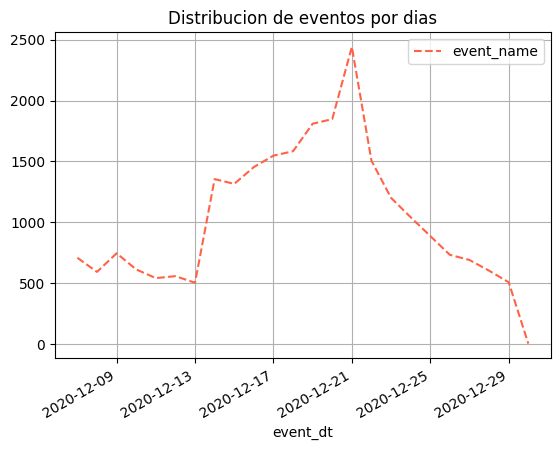

In [53]:
#Grafico de eventos por dia
df_pivot_events.plot(
    kind = 'line',
    title = 'Distribucion de eventos por dias',
    style='--',
    color='tomato',
    grid=True)

**Comments**: se tiene una tendencia estable desde el inicio del experimento hasta el dia 13. A partir de ahi comienza un crecimiento constante y significativo hasta alcanzar su pico el dia 21. Posterior a eso decrece rapidamente hasta el final del periodo.

### ¿Hay alguna peculiaridad en los datos que hay que tener en cuenta antes de iniciar la prueba A/B?

**Comments**: la unica peculiaridad que se percibe es que las muestras no se encuentran distribuidas equitativamente en la cantidad de usuarios de cada grupo. De ahi en mas se puede proceder a la generacion de la prueba A/B.

## Evaluar los resultados de la prueba A/B:

### ¿Qué puedes decir sobre los resultados de la prueba A/B?

**Comments**: con base en los resultados presentados, se visualiza que en la primera etapa del proceso si hay una diferencia positiva a favor del grupo A con respecto al grupo B, mientras que en proceso final de la compra, los resultados son muy similares.

### Utiliza una prueba z para comprobar la diferencia estadística entre las proporciones.

In [54]:
#Visualizacion de df_events_test1
df_events_test1

,user_id,event_dt,event_name,details,group,ab_test
0,831887FE7F2D6CBA,2020-12-07,purchase,4.99,A,recommender_system_test
1,831887FE7F2D6CBA,2020-12-09,purchase,99.99,A,recommender_system_test
2,831887FE7F2D6CBA,2020-12-07,product_cart,NaN,A,recommender_system_test
3,831887FE7F2D6CBA,2020-12-08,product_cart,NaN,A,recommender_system_test
4,831887FE7F2D6CBA,2020-12-09,product_cart,NaN,A,recommender_system_test
...,...,...,...,...,...,...
23904,1E6B9298415AA97A,2020-12-21,login,NaN,B,recommender_system_test
23905,1E6B9298415AA97A,2020-12-22,login,NaN,B,recommender_system_test
23906,1E6B9298415AA97A,2020-12-23,login,NaN,B,recommender_system_test
23907,1E6B9298415AA97A,2020-12-24,login,NaN,B,recommender_system_test


In [55]:
#Pivote de cantidad y tipo de eventos por dia y grupo
df_conv_pivot = df_events_test1.pivot_table(index=['event_dt','group'], values='user_id', columns='event_name', aggfunc='count', fill_value=0)
df_conv_pivot.drop(columns='product_cart', inplace=True)
df_conv_pivot.head(5)

event_name        login  product_page  purchase
event_dt   group                               
2020-12-07 A        154            96        46
           B        165           108        59
2020-12-08 A        159           108        37
           B        119            64        35
2020-12-09 A        178           106        51

In [56]:
#Groupby de suma de eventos por grupo
df_conv = df_conv_pivot.groupby('group')[['login', 'product_page', 'purchase']].sum().reset_index()
df_conv

event_name,group,login,product_page,purchase
0,A,8272,5328,2545
1,B,2565,1374,665


- Hipotesis Nula: no existe una diferencia significativa de conversion de login a product_page entre los grupos A y B.
- Hipotesis Alternativa: si existe una diferencia significativa de conversion login a product_page entre los grupos A y B.

In [57]:
#Determinar los estadisticos relevantes
control_res = df_conv[df_conv['group'] == 'A']
treatment_res = df_conv[df_conv['group'] == 'B']

control_n = control_res['login'].sum()
treatment_n = treatment_res['login'].sum()

control_suc = control_res['product_page'].sum()
treatment_suc = treatment_res['product_page'].sum()

nobs = [control_n, treatment_n]
successes = [control_suc, treatment_suc]
print(f'El numero de observaciones es: [{nobs}]')
print(f'El numero de conversiones es: [{successes}]')

El numero de observaciones es: [[8272, 2565]]
El numero de conversiones es: [[5328, 1374]]


In [58]:
#Prueba de hipotesis
alpha = 0.05
z_stat, pval = proportions_ztest(count= successes, nobs= nobs)

print(f'Estadistico Z: {z_stat:.2f}')
print(f'Valor P: {pval*100:.1f}%')

Estadistico Z: 9.88
Valor P: 0.0%


- Hipotesis Nula: no existe una diferencia significativa de conversion de product_page a purchase entre los grupos A y B.
- Hipotesis Alternativa: si existe una diferencia significativa de conversion de product_page a purchase entre los grupos A y B.

In [59]:
#Determinar los estadisticos relevantes
control_res = df_conv[df_conv['group'] == 'A']
treatment_res = df_conv[df_conv['group'] == 'B']

control_n = control_res['product_page'].sum()
treatment_n = treatment_res['product_page'].sum()

control_suc = control_res['purchase'].sum()
treatment_suc = treatment_res['purchase'].sum()

nobs = [control_n, treatment_n]
successes = [control_suc, treatment_suc]
print(f'El numero de observaciones es: [{nobs}]')
print(f'El numero de conversiones es: [{successes}]')

El numero de observaciones es: [[5328, 1374]]
El numero de conversiones es: [[2545, 665]]


In [60]:
#Prueba de hipotesis
alpha = 0.05
z_stat, pval = proportions_ztest(count= successes, nobs= nobs)

print(f'Estadistico Z: {z_stat:.2f}')
print(f'Valor P: {pval*100:.1f}%')

Estadistico Z: -0.42
Valor P: 67.6%


**Comments:** se prueban hipotesis por medio de un test de proporciones 'proportions_ztest' para las conversiones entre los eventos Login y Product_page, Product_page y Purchase. Se define el valor alpha de 5%.
- `Login y Product_page:` resulta un Valor P de 0.0%, por lo que se rechaza la hipotesis nula, ya que existe diferencia significativa en las conversiones a favor del grupo A.
- `Product_page y Purchase:` resulta un Valor P de 67.6%, por lo que NO se rechaza la hipotesis nula, ya no que existe diferencia significativa en las conversiones.

## Conclusion General

1) **Carga de librerias y conjunto de datos** 
    - *Tabla ab_project_marketing_events_us:* archivo con el calendario de eventos de marketing para 2020.
    - *Tabla final_ab_new_users_upd_us:* archivo con los usuarios que se registraron en la tienda en línea desde el 7 hasta el 21 de diciembre de 2020.
    - *Tabla final_ab_events_upd_us:* archivo con los eventos de los nuevos usuarios en el período entre el 7 de diciembre de 2020 y el 1 de enero de 2021.
    - *Tabla final_ab_participants_upd_us:* Un archivo con los datos de los participantes de la prueba.
2) **Procesamiento de los datos.**
    - *Columna "start_dt" (df_calendar):* se hace el cambio de tipo de dato para esta columna de object a datetime.
    - *Columna "finish_dt" (df_calendar):* se hace el cambio de tipo de dato para esta columna de object a datetime.
    - *Identificacion de valores duplicados (df_calendar):* no se identifican valores duplicados en lineas completas..
    - *Columna "first_date" (df_users):* se hace el cambio de tipo de dato para esta columna de object a datetime..
    - *Columna "region" (df_users):* tipo de dato adecuado. Hay 43.3k de EU, 9k de NA y 3k de CIS y APAC respectivamente.
    - *Columna "device" (df_users):* tipo de dato adecuado. Hay 26.1k Android, 14.8k de PCs, 11.9k iPhones y 5.7k Mac.
    - *Identificacion de valores duplicados (df_users):* no se identifican valores duplicados en lineas completas.
    - *Columna "user_id" (df_events):* tipo de dato adecuado. Los usuarios con mayor eventos es de +30 y la menor de 1.
    - *Columna "event_dt" (df_events):* se hace el cambio de tipo de dato para esta columna de object a datetime.
    - *Columna "event_name" (df_events):* tipo de dato Ok. Login 182k, product_page 120k, purchase 60.3k, product_cart 60.1k.
    - *Columna "details" (df_events):* tipo de dato Ok. Valor minimo 4.99 (44.5k), valor maximo 499.99 (1.1k).
    - *Identificacion de valores duplicados (df_events):* no se identifican valores duplicados en lineas completas.
    - *Columna "user_id" (df_test):* tipo de dato Ok. Hay usuarios que aparecen 2 veces en el dataset y otros solo una.
    - *Columna "group" (df_test):* tipo de dato adecuado. Se identifican 8.2k usuarios en el grupo A y 6.3k en el grupo B.
    - *Columna "ab_test" (df_test):* tipo de dato adecuado. 10.8k pruebas de interface y 3.6k pruebas de recommender.
    - *Identificacion de valores duplicados (df_test):* no se identifican valores duplicados en lineas completas.
3) **Analisis Exploratorio.**
    - *Estudia la conversión en las diferentes etapas del embudo:* 
        - Para login -> product page, a partir del dia 7 se identifica la tendencia de separacion del grupo A con respecto al B con maximos de 11%, los cuales se mantienen constantes por el resto del periodo.
        - Para product page -> purchase, a partir del dia 11 se estabiliza y reduce la diferencia a favor del grupo B con respecto al A, los cuales se mantienen constantes por el resto del periodo. 
    - *¿El número de eventos por usuario está distribuido equitativamente entre las muestras?:* no se cuenta con usuarios/eventos distribuidos equitativamente. La cantidad de usuarios por grupo es casi 3 veces mas del A con respecto al B, y en el caso de los eventos es 3.5 veces mas los del A con respecto al B
    - *¿Hay usuarios que están presentes en ambas muestras?:* no se encuentran usuarios presentes en ambas muestras.
    - *¿Cómo se distribuye el número de eventos entre los días?:* se tiene una tendencia estable desde el inicio del experimento hasta el dia 13. A partir de ahi comienza un crecimiento constante y significativo hasta alcanzar su pico el dia 21. Posterior a eso decrece rapidamente hasta el final del periodo.
    - *¿Hay alguna peculiaridad en los datos que hay que tener en cuenta antes de iniciar la prueba A/B?:* la unica peculiaridad que se percibe es que las muestras no se encuentran distribuidas equitativamente en la cantidad de usuarios de cada grupo. De ahi en mas se puede proceder a la generacion de la prueba A/B.
4) **Conclusion General.**
    - *Toma una decisión basada en los resultados de la prueba:* con base en los resultados presentados, se visualiza que en la primera etapa del proceso si hay una diferencia positiva a favor del grupo A con respecto al grupo B, mientras que en proceso final de la compra, los resultados son muy similares.
    - se prueban hipotesis por medio de un test de proporciones 'proportions_ztest' para las conversiones entre los eventos Login y Product_page, Product_page y Purchase. Se define el valor alpha de 5%.
        - `Login y Product_page:` resulta un Valor P de 0.0%, por lo que se rechaza la hipotesis nula, ya que existe diferencia significativa en las conversiones a favor del grupo A.
        - `Product_page y Purchase:` resulta un Valor P de 67.6%, por lo que NO se rechaza la hipotesis nula, ya no que existe diferencia significativa en las conversiones.